<a href="https://colab.research.google.com/github/Yogeshkumar0107/24-december-test/blob/main/paper_code2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ===============================================================
# 1. UPLOAD ZIP FILE
# ===============================================================

from google.colab import files
import zipfile, os

print("📁 Please upload your underwater_dark.zip file")
uploaded = files.upload()

# get uploaded filename
for fn in uploaded.keys():
    zip_path = fn

print("Uploaded ZIP:", zip_path)

📁 Please upload your underwater_dark.zip file


Saving underwater_dark zip.zip to underwater_dark zip.zip
Uploaded ZIP: underwater_dark zip.zip


In [ ]:
# ===============================================================
# 2. EXTRACT ZIP + AUTO-DETECT FOLDERS
# ===============================================================

import os, zipfile

extract_dir = "/content/dataset"
os.makedirs(extract_dir, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Extraction complete!")

# --- AUTO-DETECT trainA, trainB, validation DIRECTORIES ---
trainA = None
trainB = None
valDir = None

for root, dirs, files in os.walk(extract_dir):
    dnames = [d.lower() for d in dirs]

    if "traina" in dnames:
        trainA = os.path.join(root, dirs[dnames.index("traina")])
    if "trainb" in dnames:
        trainB = os.path.join(root, dirs[dnames.index("trainb")])
    if "validation" in dnames or "val" in dnames:
        valDir = os.path.join(root, dirs[dnames.index("validation")]
                              if "validation" in dnames else dirs[dnames.index("val")])

# Final paths
print("Detected trainA:", trainA)
print("Detected trainB:", trainB)
print("Detected validation:", valDir)

if trainA is None or trainB is None or valDir is None:
    raise RuntimeError("❌ Dataset folders trainA/trainB/validation not found automatically!")


✅ Extraction complete!
Detected trainA: /content/dataset/underwater_dark/trainA
Detected trainB: /content/dataset/underwater_dark/trainB
Detected validation: /content/dataset/underwater_dark/validation


In [ ]:
# ===============================================================
# 3. IMPORTS + DATASET CLASS
# ===============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import os

class UnderwaterDataset(Dataset):
    def __init__(self, low_dir, high_dir, img_size=256):
        self.low_dir = low_dir
        self.high_dir = high_dir

        self.low_files = sorted([f for f in os.listdir(low_dir)
                                 if f.lower().endswith(("jpg","jpeg","png"))])
        self.high_files = sorted([f for f in os.listdir(high_dir)
                                  if f.lower().endswith(("jpg","jpeg","png"))])

        n = min(len(self.low_files), len(self.high_files))
        self.low_files  = self.low_files[:n]
        self.high_files = self.high_files[:n]

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.low_files)

    def __getitem__(self, idx):
        low  = Image.open(os.path.join(self.low_dir,  self.low_files[idx])).convert("RGB")
        high = Image.open(os.path.join(self.high_dir, self.high_files[idx])).convert("RGB")
        return self.transform(low), self.transform(high)


In [ ]:
# ===============================================================
# 4. MODEL + LOSS FUNCTIONS (FULL)
# ===============================================================

# ------------------ SSIM LOSS ------------------ #

class SSIMLoss(nn.Module):
    def __init__(self, window_size=11):
        super().__init__()
        self.window_size = window_size

        sigma = 1.5
        coords = torch.arange(window_size).float() - window_size // 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        g = g / g.sum()
        gauss_2d = g[:, None] * g[None, :]
        window = gauss_2d.unsqueeze(0).unsqueeze(0)
        self.register_buffer("window", window)

        self.C1 = 0.01 ** 2
        self.C2 = 0.03 ** 2

    def _filter(self, x):
        window = self.window.expand(x.size(1), 1, self.window_size, self.window_size)
        window = window.to(x.device)
        return F.conv2d(x, window, padding=self.window_size // 2, groups=x.size(1))

    def forward(self, x, y):
        mu_x = self._filter(x)
        mu_y = self._filter(y)

        sigma_x2 = self._filter(x * x) - mu_x * mu_x
        sigma_y2 = self._filter(y * y) - mu_y * mu_y
        sigma_xy = self._filter(x * y) - mu_x * mu_y

        ssim = ((2 * mu_x * mu_y + self.C1) *
                (2 * sigma_xy + self.C2)) / (
                (mu_x * mu_x + mu_y * mu_y + self.C1) *
                (sigma_x2 + sigma_y2 + self.C2))

        return 1 - ssim.mean()

# ------------------ PERCEPTUAL LOSS ------------------ #

class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
        self.slice = nn.Sequential()

        for i in range(16):
            self.slice.add_module(str(i), vgg[i])

        for p in self.slice.parameters():
            p.requires_grad = False

        self.register_buffer("mean", torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer("std",  torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))

    def forward(self, x, y):
        x = (x - self.mean) / self.std
        y = (y - self.mean) / self.std
        fx = self.slice(x)
        fy = self.slice(y)
        return F.l1_loss(fx, fy)

# ------------------ BLOCKS ------------------ #

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, k=3, s=1, p=1, act=True):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, k, s, p, bias=False)
        self.bn = nn.BatchNorm2d(out_c)
        self.act = nn.ReLU(inplace=True) if act else nn.Identity()

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class ResidualBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.b1 = ConvBlock(c, c)
        self.b2 = ConvBlock(c, c, act=False)

    def forward(self, x):
        return F.relu(self.b2(self.b1(x)) + x, inplace=True)

# ------------------ LPPNet ------------------ #

class LPPNet(nn.Module):
    def __init__(self, in_ch=3, base=32):
        super().__init__()
        self.e1 = ConvBlock(in_ch, base)
        self.e2 = ConvBlock(base, base*2, s=2)
        self.e3 = ConvBlock(base*2, base*4, s=2)
        self.res = nn.Sequential(ResidualBlock(base*4), ResidualBlock(base*4))
        self.u2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.d2 = ConvBlock(base*4, base*2)
        self.u1 = nn.Upsample(scale_factor=2)
        self.d1 = ConvBlock(base*2, base)
        self.out = nn.Conv2d(base, 3, 3, padding=1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        r = self.res(e3)
        x = self.d2(self.u2(r))
        x = self.d1(self.u1(x))
        return torch.sigmoid(self.out(x))

# ------------------ DENet ------------------ #

class DENet(LPPNet):
    pass

# ------------------ FusionNet ------------------ #

class FusionNet(nn.Module):
    def __init__(self, in_ch=6, base=32):
        super().__init__()
        self.c1 = ConvBlock(in_ch, base)
        self.res = nn.Sequential(ResidualBlock(base), ResidualBlock(base))
        self.out = nn.Conv2d(base, 3, 3, padding=1)

    def forward(self, x):
        x = self.c1(x)
        x = self.res(x)
        return torch.sigmoid(self.out(x))

# ------------------ DualEnhance ------------------ #

class DualEnhance(nn.Module):
    def __init__(self):
        super().__init__()
        self.lpp = LPPNet()
        self.de  = DENet()
        self.fuse = FusionNet(in_ch=6)

    def forward(self, x):
        a = self.lpp(x)
        b = self.de(x)
        f = torch.cat([a, b], dim=1)
        return self.fuse(f)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

train_dataset = UnderwaterDataset(trainA, trainB)
val_dataset   = UnderwaterDataset(valDir, trainB)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)

model = DualEnhance().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

l1_loss_fn   = nn.L1Loss()
ssim_loss_fn = SSIMLoss().to(device)
perc_loss_fn = PerceptualLoss().to(device)

epochs = 5


Device: cuda


In [ ]:
save_dir = "/content/output_results"
os.makedirs(f"{save_dir}/samples", exist_ok=True)
os.makedirs(f"{save_dir}/models", exist_ok=True)
os.makedirs(f"{save_dir}/graphs", exist_ok=True)

print("Output folders ready!")


Output folders ready!


In [ ]:
# ===============================================================
# 7. TRAINING LOOP
# ===============================================================

train_losses = []
val_losses = []
best_val = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for low, high in train_loader:
        low, high = low.to(device), high.to(device)

        optimizer.zero_grad()
        pred = model(low)

        loss = (
            l1_loss_fn(pred, high)
            + 0.2 * ssim_loss_fn(pred, high)
            + 0.1 * perc_loss_fn(pred, high)
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # -------- VALIDATION --------
    val_total = 0
    model.eval()
    with torch.no_grad():
        for low, high in val_loader:
            low, high = low.to(device), high.to(device)
            pred = model(low)
            val_total += l1_loss_fn(pred, high).item()

    val_loss = val_total / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train={train_loss:.4f} | Val={val_loss:.4f}")

    # SAVE SAMPLE OUTPUT
    sample_low  = low[0].cpu().permute(1,2,0)
    sample_high = high[0].cpu().permute(1,2,0)
    sample_pred = pred[0].detach().cpu().permute(1,2,0)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(sample_low);  plt.axis("off"); plt.title("Low")
    plt.subplot(1,3,2); plt.imshow(sample_pred); plt.axis("off"); plt.title("Prediction")
    plt.subplot(1,3,3); plt.imshow(sample_high); plt.axis("off"); plt.title("Ground Truth")
    plt.savefig(f"{save_dir}/samples/epoch_{epoch+1}.png")
    plt.close()

    # SAVE BEST MODEL
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), f"{save_dir}/models/best_model.pth")
        print("✔ Best model saved")

print("Training Complete!")


Epoch 1/5 | Train=0.2891 | Val=0.2917
✔ Best model saved
Epoch 2/5 | Train=0.2411 | Val=0.2857
✔ Best model saved
Epoch 3/5 | Train=0.2252 | Val=0.2821
✔ Best model saved
Epoch 4/5 | Train=0.2166 | Val=0.2788
✔ Best model saved
Epoch 5/5 | Train=0.2099 | Val=0.2776
✔ Best model saved
Training Complete!


In [ ]:
# ===============================================================
# 8. SAVE LOSS GRAPH
# ===============================================================

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.legend()
plt.title("Loss Curve")
plt.savefig(f"{save_dir}/graphs/loss_curve.png")
plt.close()

print("🎉 Training complete!")
print("All outputs saved in:", save_dir)


🎉 Training complete!
All outputs saved in: /content/output_results


Train images: 5550 | GT images: 5550
Device: cuda
Output folders ready at: /content/output_results
Epoch 1/5 | Train Loss=0.2933 | Val Loss=0.2753 | Val PSNR=9.44 | Val SSIM=0.127 | Val Acc=0.00
✔ Best model saved
Epoch 2/5 | Train Loss=0.2464 | Val Loss=0.2773 | Val PSNR=9.36 | Val SSIM=0.121 | Val Acc=0.00
Epoch 3/5 | Train Loss=0.2288 | Val Loss=0.2798 | Val PSNR=9.28 | Val SSIM=0.122 | Val Acc=0.00
Epoch 4/5 | Train Loss=0.2182 | Val Loss=0.2790 | Val PSNR=9.30 | Val SSIM=0.115 | Val Acc=0.00
Epoch 5/5 | Train Loss=0.2118 | Val Loss=0.2765 | Val PSNR=9.40 | Val SSIM=0.118 | Val Acc=0.00
✅ Training complete!


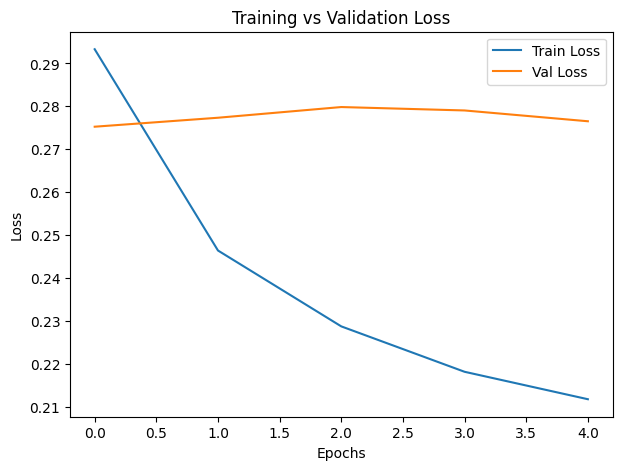

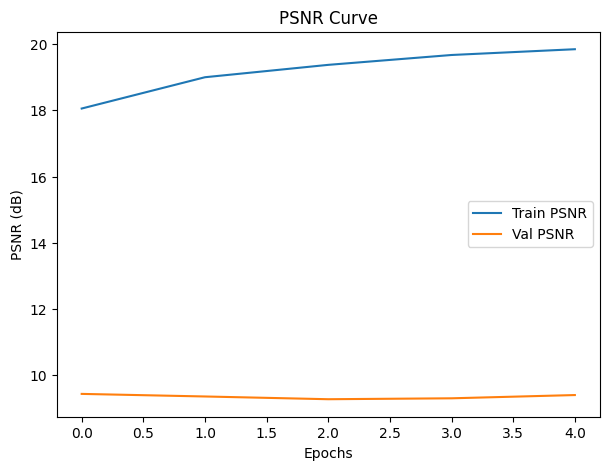

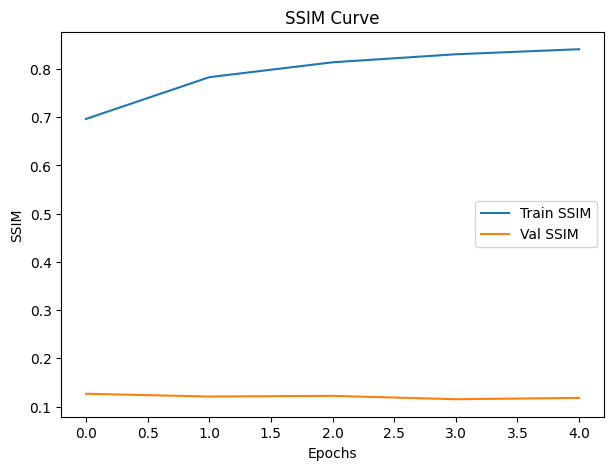

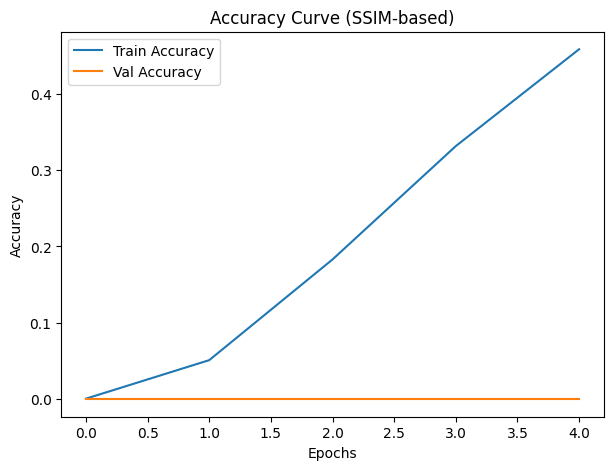

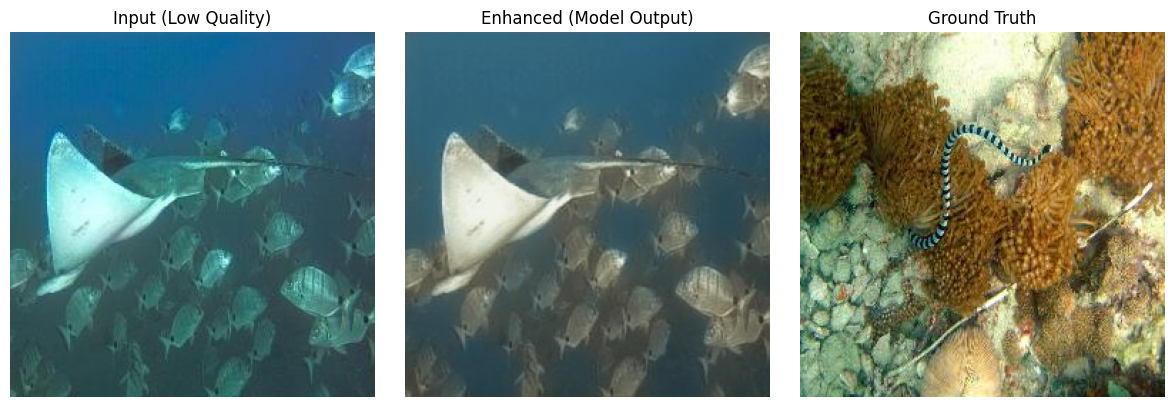

📊 All graphs and results saved in: /content/output_results


In [ ]:
# ===============================================================
# 3. IMPORTS + DATASET CLASS
# ===============================================================

import torch, math
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt

class UnderwaterDataset(Dataset):
    def __init__(self, low_dir, high_dir, img_size=256):
        self.low_dir = low_dir
        self.high_dir = high_dir

        self.low_files = sorted([f for f in os.listdir(low_dir)
                                 if f.lower().endswith(("jpg","jpeg","png"))])
        self.high_files = sorted([f for f in os.listdir(high_dir)
                                  if f.lower().endswith(("jpg","jpeg","png"))])

        n = min(len(self.low_files), len(self.high_files))
        self.low_files  = self.low_files[:n]
        self.high_files = self.high_files[:n]

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.low_files)

    def __getitem__(self, idx):
        low  = Image.open(os.path.join(self.low_dir,  self.low_files[idx])).convert("RGB")
        high = Image.open(os.path.join(self.high_dir, self.high_files[idx])).convert("RGB")
        return self.transform(low), self.transform(high)

print("Train images:", len(os.listdir(trainA)), "| GT images:", len(os.listdir(trainB)))

# ===============================================================
# 4. MODEL + LOSS FUNCTIONS
# ===============================================================

# ------------------ SSIM LOSS ------------------ #
class SSIMLoss(nn.Module):
    def __init__(self, window_size=11):
        super().__init__()
        self.window_size = window_size

        sigma = 1.5
        coords = torch.arange(window_size).float() - window_size // 2
        g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
        g = g / g.sum()
        gauss_2d = g[:, None] * g[None, :]
        window = gauss_2d.unsqueeze(0).unsqueeze(0)
        self.register_buffer("window", window)

        self.C1 = 0.01 ** 2
        self.C2 = 0.03 ** 2

    def _filter(self, x):
        window = self.window.expand(x.size(1), 1, self.window_size, self.window_size)
        window = window.to(x.device)
        return F.conv2d(x, window, padding=self.window_size // 2, groups=x.size(1))

    def forward(self, x, y):
        mu_x = self._filter(x)
        mu_y = self._filter(y)

        sigma_x2 = self._filter(x * x) - mu_x * mu_x
        sigma_y2 = self._filter(y * y) - mu_y * mu_y
        sigma_xy = self._filter(x * y) - mu_x * mu_y

        ssim_map = ((2 * mu_x * mu_y + self.C1) *
                    (2 * sigma_xy + self.C2)) / (
                    (mu_x * mu_x + mu_y * mu_y + self.C1) *
                    (sigma_x2 + sigma_y2 + self.C2))

        return 1 - ssim_map.mean()

# ------------------ PERCEPTUAL LOSS ------------------ #
class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features
        self.slice = nn.Sequential()
        for i in range(16):  # up to relu3_3
            self.slice.add_module(str(i), vgg[i])

        for p in self.slice.parameters():
            p.requires_grad = False

        self.register_buffer("mean", torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer("std",  torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))

    def forward(self, x, y):
        x = (x - self.mean) / self.std
        y = (y - self.mean) / self.std
        fx = self.slice(x)
        fy = self.slice(y)
        return F.l1_loss(fx, fy)

# ------------------ BASIC BLOCKS ------------------ #
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, k=3, s=1, p=1, act=True):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, k, s, p, bias=False)
        self.bn = nn.BatchNorm2d(out_c)
        self.act = nn.ReLU(inplace=True) if act else nn.Identity()

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class ResidualBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.b1 = ConvBlock(c, c)
        self.b2 = ConvBlock(c, c, act=False)

    def forward(self, x):
        return F.relu(self.b2(self.b1(x)) + x, inplace=True)

# ------------------ LPPNet ------------------ #
class LPPNet(nn.Module):
    def __init__(self, in_ch=3, base=32):
        super().__init__()
        self.e1 = ConvBlock(in_ch, base)
        self.e2 = ConvBlock(base, base*2, s=2)
        self.e3 = ConvBlock(base*2, base*4, s=2)

        self.res = nn.Sequential(ResidualBlock(base*4), ResidualBlock(base*4))

        self.u2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.d2 = ConvBlock(base*4, base*2)
        self.u1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.d1 = ConvBlock(base*2, base)
        self.out = nn.Conv2d(base, 3, 3, padding=1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)

        r = self.res(e3)

        x = self.u2(r)
        x = self.d2(x)
        x = self.u1(x)
        x = self.d1(x)
        x = self.out(x)
        return torch.sigmoid(x)

# ------------------ DENet (same as LPPNet) ------------------ #
class DENet(LPPNet):
    pass

# ------------------ FusionNet ------------------ #
class FusionNet(nn.Module):
    def __init__(self, in_ch=6, base=32):
        super().__init__()
        self.c1 = ConvBlock(in_ch, base)
        self.res = nn.Sequential(ResidualBlock(base), ResidualBlock(base))
        self.out = nn.Conv2d(base, 3, 3, padding=1)

    def forward(self, x):
        x = self.c1(x)
        x = self.res(x)
        x = self.out(x)
        return torch.sigmoid(x)

# ------------------ DualEnhance ------------------ #
class DualEnhance(nn.Module):
    def __init__(self):
        super().__init__()
        self.lpp = LPPNet()
        self.de  = DENet()
        self.fuse = FusionNet(in_ch=6)

    def forward(self, x):
        a = self.lpp(x)
        b = self.de(x)
        f = torch.cat([a, b], dim=1)
        return self.fuse(f)

# ===============================================================
# 5. METRICS (PSNR, SSIM, ACCURACY)
# ===============================================================

def psnr_metric(pred, target):
    mse = F.mse_loss(pred, target).item()
    if mse == 0:
        return 100
    return 20 * math.log10(1.0 / math.sqrt(mse))

def ssim_metric(pred, target):
    # SSIMLoss returns (1 - ssim), so we invert it
    return 1 - ssim_loss_fn(pred, target).item()

def accuracy_metric(pred, target, threshold=0.85):
    """Accuracy = % images with SSIM >= threshold."""
    ssim_value = ssim_metric(pred, target)
    return 1 if ssim_value >= threshold else 0

# ===============================================================
# 6. TRAINING SETUP
# ===============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

train_dataset = UnderwaterDataset(trainA, trainB, img_size=256)
val_dataset   = UnderwaterDataset(valDir, trainB, img_size=256)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)

model = DualEnhance().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

l1_loss_fn   = nn.L1Loss()
ssim_loss_fn = SSIMLoss().to(device)
perc_loss_fn = PerceptualLoss().to(device)

epochs = 5

# ===============================================================
# 7. OUTPUT DIRECTORIES
# ===============================================================

save_dir = "/content/output_results"
os.makedirs(f"{save_dir}/samples", exist_ok=True)
os.makedirs(f"{save_dir}/models", exist_ok=True)
os.makedirs(f"{save_dir}/graphs", exist_ok=True)

print("Output folders ready at:", save_dir)

# ===============================================================
# 8. TRAINING LOOP WITH METRICS
# ===============================================================

train_losses, val_losses = [], []
train_psnr_list, val_psnr_list = [], []
train_ssim_list, val_ssim_list = [], []
train_acc_list,  val_acc_list  = [], []

best_val = float("inf")

for epoch in range(epochs):
    model.train()
    running_loss = 0
    running_psnr = 0
    running_ssim = 0
    running_acc  = 0

    for low, high in train_loader:
        low, high = low.to(device), high.to(device)

        optimizer.zero_grad()
        pred = model(low)

        loss = (
            l1_loss_fn(pred, high)
            + 0.2 * ssim_loss_fn(pred, high)
            + 0.1 * perc_loss_fn(pred, high)
        )
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_psnr += psnr_metric(pred, high)
        running_ssim += ssim_metric(pred, high)
        running_acc  += accuracy_metric(pred, high)

    train_losses.append(running_loss / len(train_loader))
    train_psnr_list.append(running_psnr / len(train_loader))
    train_ssim_list.append(running_ssim / len(train_loader))
    train_acc_list.append(running_acc / len(train_loader))

    # ---------------- VALIDATION ----------------
    model.eval()
    val_loss = 0
    val_psnr = 0
    val_ssim = 0
    val_acc  = 0

    with torch.no_grad():
        for low, high in val_loader:
            low, high = low.to(device), high.to(device)
            pred = model(low)

            val_loss += l1_loss_fn(pred, high).item()
            val_psnr += psnr_metric(pred, high)
            val_ssim += ssim_metric(pred, high)
            val_acc  += accuracy_metric(pred, high)

        val_losses.append(val_loss / len(val_loader))
        val_psnr_list.append(val_psnr / len(val_loader))
        val_ssim_list.append(val_ssim / len(val_loader))
        val_acc_list.append(val_acc / len(val_loader))

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss={train_losses[-1]:.4f} | Val Loss={val_losses[-1]:.4f} | "
          f"Val PSNR={val_psnr_list[-1]:.2f} | Val SSIM={val_ssim_list[-1]:.3f} | "
          f"Val Acc={val_acc_list[-1]:.2f}")

    # Save sample from last batch of epoch
    sample_low  = low[0].cpu().permute(1,2,0)
    sample_high = high[0].cpu().permute(1,2,0)
    sample_pred = pred[0].detach().cpu().permute(1,2,0)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(sample_low);  plt.axis("off"); plt.title("Low")
    plt.subplot(1,3,2); plt.imshow(sample_pred); plt.axis("off"); plt.title("Predicted")
    plt.subplot(1,3,3); plt.imshow(sample_high); plt.axis("off"); plt.title("Ground Truth")
    plt.savefig(f"{save_dir}/samples/epoch_{epoch+1}.png")
    plt.close()

    # Save best model
    if val_losses[-1] < best_val:
        best_val = val_losses[-1]
        torch.save(model.state_dict(), f"{save_dir}/models/best_model.pth")
        print("✔ Best model saved")

print("✅ Training complete!")

# ===============================================================
# 9. PLOT GRAPHS (LOSS, PSNR, SSIM, ACCURACY)
# ===============================================================

# 1. Loss Graph
plt.figure(figsize=(7,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig(f"{save_dir}/graphs/loss_curve.png")
plt.show()

# 2. PSNR Graph
plt.figure(figsize=(7,5))
plt.plot(train_psnr_list, label="Train PSNR")
plt.plot(val_psnr_list, label="Val PSNR")
plt.title("PSNR Curve")
plt.xlabel("Epochs")
plt.ylabel("PSNR (dB)")
plt.legend()
plt.savefig(f"{save_dir}/graphs/psnr_curve.png")
plt.show()

# 3. SSIM Graph
plt.figure(figsize=(7,5))
plt.plot(train_ssim_list, label="Train SSIM")
plt.plot(val_ssim_list, label="Val SSIM")
plt.title("SSIM Curve")
plt.xlabel("Epochs")
plt.ylabel("SSIM")
plt.legend()
plt.savefig(f"{save_dir}/graphs/ssim_curve.png")
plt.show()

# 4. Accuracy Graph
plt.figure(figsize=(7,5))
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Val Accuracy")
plt.title("Accuracy Curve (SSIM-based)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig(f"{save_dir}/graphs/accuracy_curve.png")
plt.show()

# ===============================================================
# 10. BEFORE–AFTER COMPARISON GRAPH
# ===============================================================

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(sample_low)
plt.title("Input (Low Quality)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(sample_pred)
plt.title("Enhanced (Model Output)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(sample_high)
plt.title("Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.savefig(f"{save_dir}/graphs/before_after_comparison.png")
plt.show()

print("📊 All graphs and results saved in:", save_dir)